
# DL Assignment 03

**Name:** subrata saha

**Course Email:**  subratabaec@gmail.com


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# General Instruction

You must choose your own dataset.

The dataset must:

Be a supervised learning dataset (Regression or Binary Classification)

Contain at least 300 samples

Have at least 2 input features

Be in CSV format

You are NOT allowed to use Dataset or DataLoader.

You must implement everything manually.

# Question 01: [ Marks 05 ]

## Dataset Preparation

## Using your chosen dataset:

Load the dataset.

Perform necessary preprocessing:

Handle missing values (if any)

Encode categorical variables (if necessary)

Feature scaling (if needed)

Separate features (X) and target (y).

Convert them into NumPy arrays.

Convert them into PyTorch tensors.

Split into training and testing sets.

Clearly explain each preprocessing decision.

# Answer 01:


In [68]:
import pandas as pd
import numpy as np
import torch

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

!pip install torchinfo

# Load dataset
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseValue"] = data.target # target variable

In [69]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


#### Explanation:
- no categorical variable. No need of encoding.

In [71]:
print(df.isnull().sum())

MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64


##### Explanation:
- No missing values.

In [72]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#### Explanation:
- "Population",	"AveOccup" have larger values. Need scaling.

In [73]:
X = df.drop("MedHouseValue", axis=1)
y = df["MedHouseValue"]

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [76]:
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

In [77]:
X.shape

(20640, 8)

In [78]:
print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [79]:
# Converting from numpy to tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.from_numpy(y_train.values).float().view(-1,1)
y_test_tensor = torch.from_numpy(y_test.values).float().view(-1,1)

# y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
# y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [80]:
print(type(X_train_tensor))
print(type(X_test_tensor))
print(type(y_train_tensor))
print(type(y_test_tensor))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


# Question 02: [ Marks 20 ]

## Design a neural network using nn.Module.

### The model must contain:

Input layer

At least one hidden layer

Output layer

Suitable activation function



## Justify:

Number of hidden neurons

Choice of activation function

Print  the total number of trainable parameters.


## Answer 02:
- An ANN architecture with 2 hidden layers.
- Input-16 nuerons-8 neurons-1 neuron architecture
- Relu Activation function


In [81]:
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        # Input to Hidden Layer 1
        self.linear1 = nn.Linear(num_features, 16)
        self.relu1 = nn.ReLU()

        # Hidden Layer 1 to Hidden Layer 2
        self.linear2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()

        # Hidden Layer 2 to Output
        self.linear3 = nn.Linear(8, 1)
        self.relu3 = nn.ReLU()

    def forward(self, features):
        # Input to Hidden Layer 1
        out = self.linear1(features)
        out = self.relu1(out)

        # Hidden Layer 1 to Hidden Layer 2
        out = self.linear2(out)
        out = self.relu2(out)

        # Hidden Layer 2 to Output
        out = self.linear3(out)   # (using Relu activation)
        out = self.relu3(out)

        return out

In [82]:
model = Model(X_train_tensor.shape[1])
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

Total trainable parameters: 289


In [83]:
X_train_tensor.shape

torch.Size([16512, 8])

In [84]:
# Summary
from torchinfo import summary
summary(model, input_size = (16512, 8))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [16512, 1]                --
├─Linear: 1-1                            [16512, 16]               144
├─ReLU: 1-2                              [16512, 16]               --
├─Linear: 1-3                            [16512, 8]                136
├─ReLU: 1-4                              [16512, 8]                --
├─Linear: 1-5                            [16512, 1]                9
├─ReLU: 1-6                              [16512, 1]                --
Total params: 289
Trainable params: 289
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.77
Input size (MB): 0.53
Forward/backward pass size (MB): 3.30
Params size (MB): 0.00
Estimated Total Size (MB): 3.83

#### Explanations:
- The network contains two hidden layers with 16 and 8 neurons. The first hidden layer expands the input feature space to capture complex relationships, while the second layer compresses it to retain the most relevant information.
- ReLU activation is used in the hidden layers to introduce non linearity and enable efficient training.
- Relu activation is used in the output layer since the task is regression and to ensure the lowest output is 0.
- The model has a total of 289 trainable parameters.

# Question 03: [ Marks 10 ]

Choose an appropriate loss function.

Choose an optimizer.

<br>

Justify your choices based on:

Regression vs Classification

Nature of the dataset

## Answer 03:

In [85]:
# no. of features
X_train.shape[1]

8

In [86]:
learning_rate = 0.01
epochs = 100

In [87]:
# loss function
loss_function = nn.MSELoss()  # MSE for regression

# model
model = Model(X_train_tensor.shape[1])

#optimizer - SGD
optimizer = torch.optim.SGD( model.parameters(), lr = learning_rate )

#### Explanation:
- Since the problem is regression, the Mean Squared Error (MSE) loss is chosen.
- SGD is chosen as the optimizer. Full batch SGD is used to save the processing time.

# Question 04: [ Marks 15 ]

## Implement a full training loop:

Forward pass

Loss computation

Backward pass

Parameter update

Gradient reset

### Requirements:

Train for at least 100 epochs.

Print loss every 10 epochs.

Store training loss history(You can pick your own Data Structure).

Explain clearly what happens in each step of the pipeline.

## Answer 04: Full Pipeline

In [88]:
# model
model = Model(X_train_tensor.shape[1])

# loss function
MSE_loss_function = nn.MSELoss() # MSE
MAE_loss_function = nn.L1Loss() # MAE

# learning rate
learning_rate = 0.01

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# epochs
epochs = 1000
training_loss_history = []  # for storing loss values in a list

In [89]:
for epochs in range(epochs):

    # Forward
    y_pred = model(X_train_tensor) # this is full batch SGD

    # loss calculation
    loss = MSE_loss_function(y_pred, y_train_tensor)

    # Zero gradient
    optimizer.zero_grad()

    # Backward
    loss.backward()

    # Update parameters
    optimizer.step()

    # store loss values
    training_loss_history.append(loss.item())

In [90]:
size=len(training_loss_history)
print(f"Training loss: {training_loss_history[size-1]}")

Training loss: 0.45383358001708984


In [91]:
for i in range(0, len(training_loss_history), 10):

  print(f"epoch no: {i+1} , loss={training_loss_history[i]} ")

epoch no: 1 , loss=5.171843528747559 
epoch no: 11 , loss=3.2480907440185547 
epoch no: 21 , loss=1.9144372940063477 
epoch no: 31 , loss=1.293983817100525 
epoch no: 41 , loss=1.039363145828247 
epoch no: 51 , loss=0.9089710116386414 
epoch no: 61 , loss=0.8279972076416016 
epoch no: 71 , loss=0.774480938911438 
epoch no: 81 , loss=0.7384890913963318 
epoch no: 91 , loss=0.7135477662086487 
epoch no: 101 , loss=0.6953797936439514 
epoch no: 111 , loss=0.6815207004547119 
epoch no: 121 , loss=0.6704245209693909 
epoch no: 131 , loss=0.6611948013305664 
epoch no: 141 , loss=0.653276264667511 
epoch no: 151 , loss=0.6463563442230225 
epoch no: 161 , loss=0.6401401162147522 
epoch no: 171 , loss=0.6344954967498779 
epoch no: 181 , loss=0.6292913556098938 
epoch no: 191 , loss=0.6244487762451172 
epoch no: 201 , loss=0.619877815246582 
epoch no: 211 , loss=0.6155297756195068 
epoch no: 221 , loss=0.6113871335983276 
epoch no: 231 , loss=0.6074342727661133 
epoch no: 241 , loss=0.6036356687

In [92]:
# print(training_loss_history)

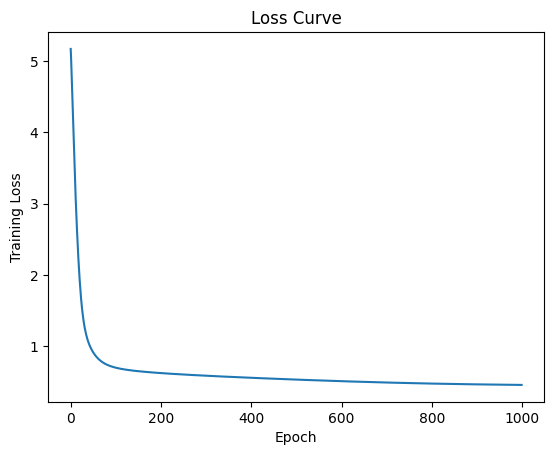

In [93]:
# Plot Training loss vs epochs
import matplotlib.pyplot as plt

plt.plot(training_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Loss Curve")
plt.show()

### Explanations:
- first, a forward pass computes predictions from input features using the neural network.
- Then, the loss is calculated using MSE between predictions and true values.
- Before computing gradients, previous gradients are cleared.
- The backward pass computes gradients of the loss with respect to each parameter.
- optimizer.step() updates the weights using these gradients.
- Training loss is stored in a list for storage.
- print for every 10 epochs and a visualization is added.
- The training loss gradually decreases with epochs.
- Full batch SGD is used as the optimizer.

# Question 05: [ Marks 10 ]

## Evaluate the model on test data.

## For regression:

Report MSE and MAE


## For classification:

Report Accuracy

Compare training vs testing performance.

State whether the model is underfitting or overfitting.

## Answer 05:


In [94]:
# MSE
mse_loss = nn.MSELoss()

# MAE=L1 loss
mae_loss = nn.L1Loss()

# Forward pass on test data
with torch.no_grad():  # No gradients needed for evaluation
    y_test_pred = model(X_test_tensor)

    # Compute MSE and MAE
    mse = mse_loss(y_test_pred, y_test_tensor)
    # mse = mse_loss(y_test_pred, y_test_tensor.reshape(-1,1))
    mae = mae_loss(y_test_pred, y_test_tensor)

print(f"Test MSE = {mse.item():.4f}")
print(f"Test MAE = {mae.item():.4f}")

Test MSE = 0.4729
Test MAE = 0.4883


In [95]:
# training_loss_history = []

# for epochs in range(epochs):

#     # Forward
#     y_pred = model(X_train_tensor)

#     # loss calculation
#     loss = MAE_loss_function(y_pred, y_train_tensor)

#     # Zero gradient
#     optimizer.zero_grad()

#     # Backward
#     loss.backward()

#     # Update parameters
#     optimizer.step()

#     # store loss values
#     training_loss_history.append(loss.item())

# size=len(training_loss_history)

# print(training_loss_history[size-1])

#### Explanations:
- cosidering MSE, the training loss is 0.45 and test loss is 0.47. both values are close. the generalizations is quite good and the model is not overfiting.
- although the accuracy is a bit low, its not underfitting also.

# Question 06: [ Marks 20 ]

## Modify at least ONE of the following:

Learning rate

Number of hidden neurons

Number of epochs

### Train again and compare:

Convergence speed

Final performance

Explain how the change affected the model.

## Answer 06:
- An ANN architecture with 3 hidden layers.
- Relu activation function.
- Modification: 1 hidden layer is added.

In [96]:
import torch.nn as nn

class Model2(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        # Input to Hidden Layer 1
        self.linear1 = nn.Linear(num_features, 16)
        self.relu1 = nn.ReLU()

        # Hidden Layer 1 to Hidden Layer 2
        self.linear2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()

        # Hidden Layer 2 to Hidden Layer 3
        self.linear3 = nn.Linear(8, 4)
        self.relu3 = nn.ReLU()

        # Hidden Layer 3 to Output
        self.linear4 = nn.Linear(4, 1)
        self.relu4 = nn.ReLU()

    def forward(self, features):
        # Input to Hidden Layer 1
        out = self.linear1(features)
        out = self.relu1(out)

        # Hidden Layer 1 to Hidden Layer 2
        out = self.linear2(out)
        out = self.relu2(out)

        # Hidden Layer 2 to Hidden Layer 3
        out = self.linear3(out)
        out = self.relu3(out)

        # Hidden Layer 2 to Output
        out = self.linear4(out)
        out = self.relu4(out)

        return out

In [105]:
# model
model = Model2(X_train_tensor.shape[1])

# loss function
MSE_loss_function = nn.MSELoss()
MAE_loss_function = nn.L1Loss()

# Learning rate
learning_rate = 0.01

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Training parameters
epochs = 1000
training_loss_history = []  # for storing loss values in a list

In [114]:
for epochs in range(epochs):

    # Forward
    y_pred = model(X_train_tensor) # this is full batch SGD

    # loss calculation
    loss = MSE_loss_function(y_pred, y_train_tensor)

    # Zero gradient
    optimizer.zero_grad()

    # Backward
    loss.backward()

    # Update parameters
    optimizer.step()

    # store loss values
    training_loss_history.append(loss.item())

In [109]:
size=len(training_loss_history)
print(training_loss_history[size-1])

0.44513264298439026


In [110]:
model = Model2(X_train_tensor.shape[1])
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

Total trainable parameters: 321


In [111]:
X_train_tensor.shape

torch.Size([16512, 8])

In [112]:
from torchinfo import summary
summary(model, input_size = (16512, 8))

Layer (type:depth-idx)                   Output Shape              Param #
Model2                                   [16512, 1]                --
├─Linear: 1-1                            [16512, 16]               144
├─ReLU: 1-2                              [16512, 16]               --
├─Linear: 1-3                            [16512, 8]                136
├─ReLU: 1-4                              [16512, 8]                --
├─Linear: 1-5                            [16512, 4]                36
├─ReLU: 1-6                              [16512, 4]                --
├─Linear: 1-7                            [16512, 1]                5
├─ReLU: 1-8                              [16512, 1]                --
Total params: 321
Trainable params: 321
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 5.30
Input size (MB): 0.53
Forward/backward pass size (MB): 3.83
Params size (MB): 0.00
Estimated Total Size (MB): 4.36

In [113]:
# MSE
mse_loss = nn.MSELoss()

# MAE=L1 loss
mae_loss = nn.L1Loss()

# Forward pass on test data
with torch.no_grad():  # No gradients needed for evaluation
    y_test_pred = model(X_test_tensor)

    # Compute MSE and MAE
    mse = mse_loss(y_test_pred, y_test_tensor)
    # mse = mse_loss(y_test_pred, y_test_tensor.reshape(-1,1))
    mae = mae_loss(y_test_pred, y_test_tensor)

print(f"Test MSE = {mse.item():.4f}")
print(f"Test MAE = {mae.item():.4f}")

Test MSE = 5.0160
Test MAE = 1.9300


#### Explanation:
- Trainable parameters are more compared to the previous model, as it has one more layer.
- Considering MSE, training loss is 0.44 and test loss is 5. Test loss is significantly higher than the 2 hidden layer architecture.
- Increasing hidden layer doesnot mean more accuracy.

# Question 07: [ Marks 20 ]


# Training Analysis

Answer the following:

Why must gradients be reset every epoch?

What happens if learning rate is too high?

What happens if learning rate is too small?

Why do we define layers inside the constructor (__init__) and not inside forward()?


## Answer 07:

1. In PyTorch, gradients are accumulated by default for every parameter whenever "loss.backward()" is called. If we do not reset gradients the new gradients will add to the previous ones, leading to incorrect updates. resetting ensures that each epochs weight update uses only the current gradient.

2. weight updating steps become too high, model may overshoot and miss the global minima.loss can oscillate too much. and even jumps up instead of decreasing.

3. weight updates in tiny steps, so it becomes a very slow process.

4. layers are defined in the "__init__" constructor because the model architecture is created there and it is saved as a pytorch model. if they are defined in the "forward()", new layers would be created with every forward pass. model can not learn properly.


### Finish